<a href="https://colab.research.google.com/github/reubyTuesday/Math509RealEstate/blob/main/USA_Dataset_Ohio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pylab inline
%config InlineBackend.figure_format = 'retina'
from ipywidgets import interact
import scipy.stats as stats
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler, StandardScaler #Scaling



Populating the interactive namespace from numpy and matplotlib


#Just Importing Ohio Set for algorithm Testing


In [2]:
from google.colab import files
uploaded = files.upload()  # This opens a file picker to upload 'subset_dataset.csv'

# Load the subset into a DataFrame
import pandas as pd
df_subset = pd.read_csv('ohio_data.csv')

Saving ohio_data.csv to ohio_data.csv


In [ ]:
df_subset.head()

## Functions

1. Delete Missing Values



In [3]:
# Function to drop missing values
def drop_missing(grp_col, col_to_check):
    nan_count_before = df[col_to_check].isna().sum()
    df.dropna(subset=[col_to_check], inplace=True)
    nan_count_after = df[col_to_check].isna().sum()

    print(f"Dropped {nan_count_before - nan_count_after} missing values from {col_to_check}.")

# Function to calculate missing values and percentage
## Code from Kaggle: https://www.kaggle.com/code/shaswotj/smart-price-prediction-using-ml
def missing_percentage(data_set):
    total_records = data_set.shape[0]
    missing_counts = data_set.isna().sum()
    missing_percentage = round(missing_counts / total_records * 100, 2)

    missing_summary = pd.DataFrame({
        'Missing Records': missing_counts,
        'Percentage Missing': missing_percentage
    })

    print(f"\nTotal number of records present: {total_records}\n")
    print(missing_summary.sort_values(by='Percentage Missing', ascending=False))
    print("\n")

# Function to imupute missing values with median
def imputer(grp_col,col_to_impute):
    imputer_df = round(df.groupby(grp_col)[col_to_impute].median(),0)
    df['helper_col'] = df[grp_col].map(imputer_df)

    nan_count_before = df[col_to_impute].isna().sum()

    df[col_to_impute] = df[col_to_impute].fillna(df['helper_col'])

    nan_count_after = df[col_to_impute].isna().sum()
    records_affected = nan_count_before - nan_count_after

    df.drop(columns = 'helper_col',inplace = True)
    print(f"Total records imputed for {col_to_impute}: {records_affected}")

In [4]:
# For example, if you have a CSV file named "real_estate.csv":
#df = pd.read_csv('realtor-data.zip.csv') #upload for full data set
df = df_subset.copy() #Just Ohio data

## Drop Missing Values
drop_missing('zip_code','bed')
drop_missing('zip_code','bath')
drop_missing('zip_code','house_size')
drop_missing('zip_code','acre_lot')
drop_missing('zip_code','price')

# Impute missing values of bed, bath, house_size, acre_lot and price using zip_code
# I am not sure exactly how we want to impute these so I am not going to run this code for now.
#imputer('zip_code','bed')
#imputer('zip_code','bath')
#imputer('zip_code','house_size')
#imputer('zip_code','acre_lot')
#imputer('zip_code','price')

###Adjusting the 'status' to dummy variable
# Remove 'ready_to_build' entries
df = df[df['status'] != 'ready_to_build']

# Convert 'for_sale' to 0 and 'sold' to 1
df['status'] = df['status'].map({'for_sale': 0, 'sold': 1})

df_cleaned = df.copy()




Dropped 0 missing values from bed.
Dropped 0 missing values from bath.
Dropped 0 missing values from house_size.
Dropped 0 missing values from acre_lot.
Dropped 0 missing values from price.


In [11]:
#Quick reset of data frame
df = df_cleaned.copy()

In [12]:
### Use Target Encoding for Zip Code - Using Median because very expensive house could have a huge impact
zip_price_map = df.groupby('zip_code')['price'].median()
df['zip_code_encoded'] = df['zip_code'].map(zip_price_map)

print(f"Unique zip codes in original data: {df['zip_code'].nunique()}")
print(f"Unique zip codes after encoding: {df['zip_code_encoded'].nunique()}")


#Some of the zip codes may share the same mean house price.

Unique zip codes in original data: 1065
Unique zip codes after encoding: 578


In [13]:
### Use Target Encoding for Street - Using Media because very expensive house could have a huge impact
street_price_map = df.groupby('street')['price'].median()
df['street_encoded'] = df['street'].map(street_price_map)

print(f"Unique streets in original data: {df['street'].nunique()}")
print(f"Unique streets after encoding: {df['street_encoded'].nunique()}")

#Many of the street may share the same mean house price.

Unique streets in original data: 38484
Unique streets after encoding: 3237


## Double Checking our Encoding Worked

In [14]:
# Compute the mean price per street
street_price_map = df.groupby('street')['price'].median()

# Group by the mean price and list all streets sharing that mean
duplicates = (street_price_map
              .reset_index()
              .groupby('price')['street']
              .apply(list)
              .reset_index())

# Filter only entries where multiple streets share the same mean price
duplicates = duplicates[duplicates['street'].apply(len) > 1]

print(duplicates)


          price                                             street
0           1.0  [81643.0, 150859.0, 153209.0, 168908.0, 179178...
7        4888.0                               [44372.0, 1378138.0]
8        5000.0           [73651.0, 625477.0, 974726.0, 1231196.0]
13       8000.0                     [287549.0, 827314.0, 890374.0]
14       8317.0  [716490.0, 1437780.0, 1498597.0, 1690512.0, 17...
...         ...                                                ...
3215  2999000.0                              [869063.0, 1223309.0]
3216  3000000.0                             [1269601.0, 1565930.0]
3219  3250000.0                   [248178.0, 1611610.0, 1731516.0]
3222  3500000.0                   [329505.0, 1060078.0, 1391624.0]
3233  5900000.0                               [507624.0, 511658.0]

[1438 rows x 2 columns]


##Ohio Reset Data df

In [15]:
data = df.copy()



## Initial Scatter Plot

      price  bed  bath  acre_lot     street  zip_code  house_size  \
0   59900.0  1.0   1.0      0.15   644465.0   43920.0       690.0   
1  279000.0  5.0   3.0      1.30  1756755.0   43920.0      3010.0   
2   75000.0  2.0   2.0      0.17   423802.0   43952.0      1080.0   
3  498900.0  4.0   4.0     13.52   461131.0   43920.0      2482.0   
4   33000.0  3.0   1.0      0.08  1807352.0   43920.0      1518.0   

   zip_code_encoded  street_encoded  
0          129000.0         59900.0  
1          129000.0        279000.0  
2           99900.0         75000.0  
3          129000.0        498900.0  
4          129000.0         33000.0  


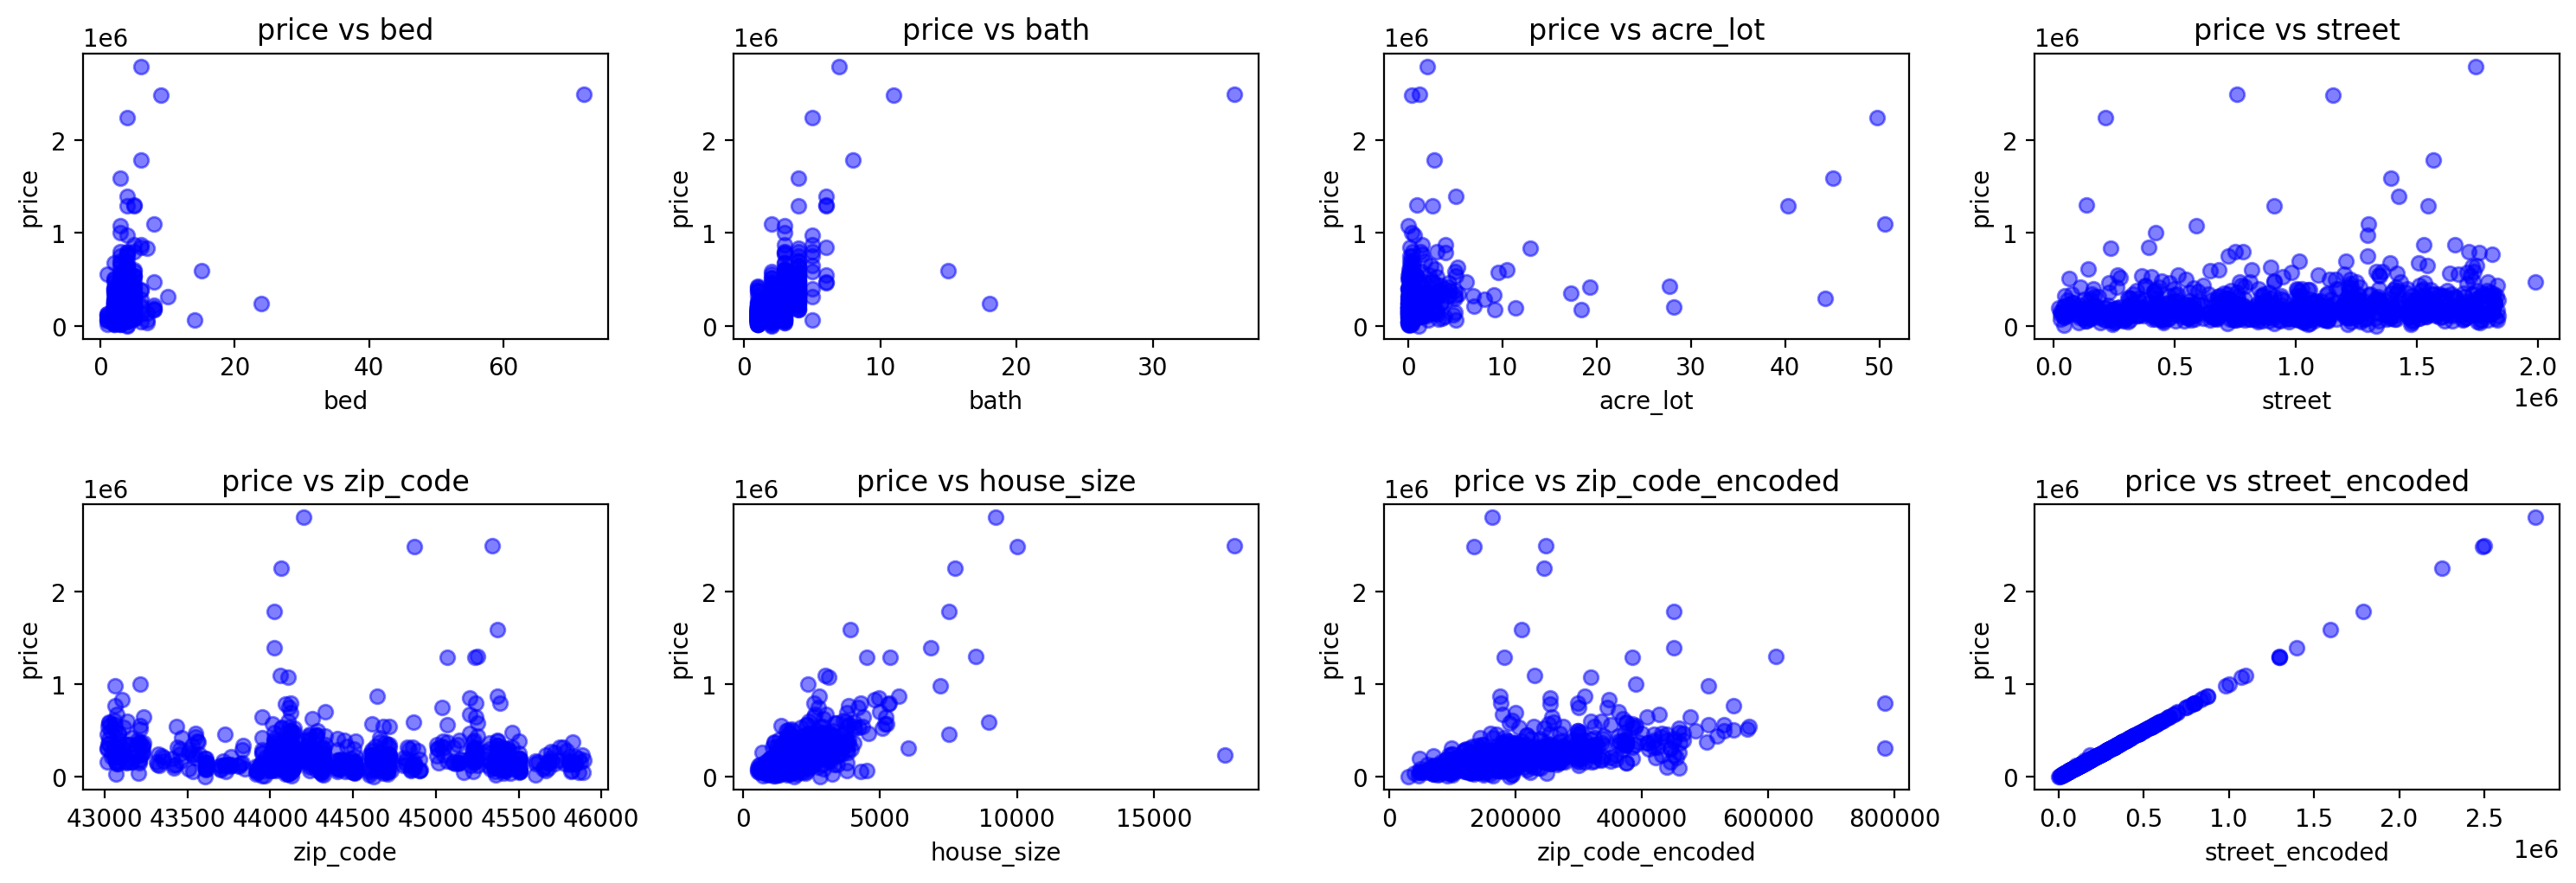

In [17]:
import matplotlib.pyplot as plt

# Create a copy of df
dfvs = df.copy()

# Drop unwanted columns
dfvs.drop(columns=['brokered_by', 'status', 'city', 'state', 'prev_sold_date'], inplace=True)

# Print the first 5 rows to verify
print(dfvs.head())

# Define the response variable (target) - not strictly needed if you're just plotting
y_response = dfvs['price']

# Create a list of predictors (exclude 'price')
predictor_cols = [col for col in dfvs.columns if col != 'price']

# Subset the DataFrame to every 50th row (adjust as desired)
dfvs_subset = dfvs.iloc[::50]

# Set figure size
plt.figure(figsize=(15, 10))

# We'll use a grid that can accommodate the number of predictors.
# If you have fewer than 9 predictors, a 3x3 grid will work well.
for i, col in enumerate(predictor_cols):
    plt.subplot(4, 4, i + 1)  # Adjust rows and columns as needed
    plt.scatter(dfvs_subset[col], dfvs_subset['price'], color='blue', alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('price')
    plt.title(f'price vs {col}')

plt.tight_layout()
plt.show()


## Remove Unnecessary Columns
City, Street, Zip-code and are all locations and they are captured in zip-code encoded feature.

Brokered by is just the broker for the deal, probably not predictive.
Street-encoded has too many values that only one property was for sale on a street so the median is the only value and has too much coorelation with price.

In [ ]:
##Remove Unnecessary Columns
data.drop(columns=['status', 'state', 'brokered_by', 'city', 'street', 'prev_sold_date', 'zip_code', 'street_encoded'], inplace=True)

# Handle missing values (fill NaNs with column mean or drop rows)
data = data.dropna() # Drop any NANs


# Display the entire dataset
print(data.describe())
data.shape

#Features - status, price, bed, bath, acre_lot, house_size, zip_code_encoded

##Remove 99th Percentile


      price  bed  bath  acre_lot     street  zip_code  house_size  \
0   59900.0  1.0   1.0      0.15   644465.0   43920.0       690.0   
1  279000.0  5.0   3.0      1.30  1756755.0   43920.0      3010.0   
2   75000.0  2.0   2.0      0.17   423802.0   43952.0      1080.0   
3  498900.0  4.0   4.0     13.52   461131.0   43920.0      2482.0   
4   33000.0  3.0   1.0      0.08  1807352.0   43920.0      1518.0   

   zip_code_encoded  street_encoded  
0          129000.0         59900.0  
1          129000.0        279000.0  
2           99900.0         75000.0  
3          129000.0        498900.0  
4          129000.0         33000.0  


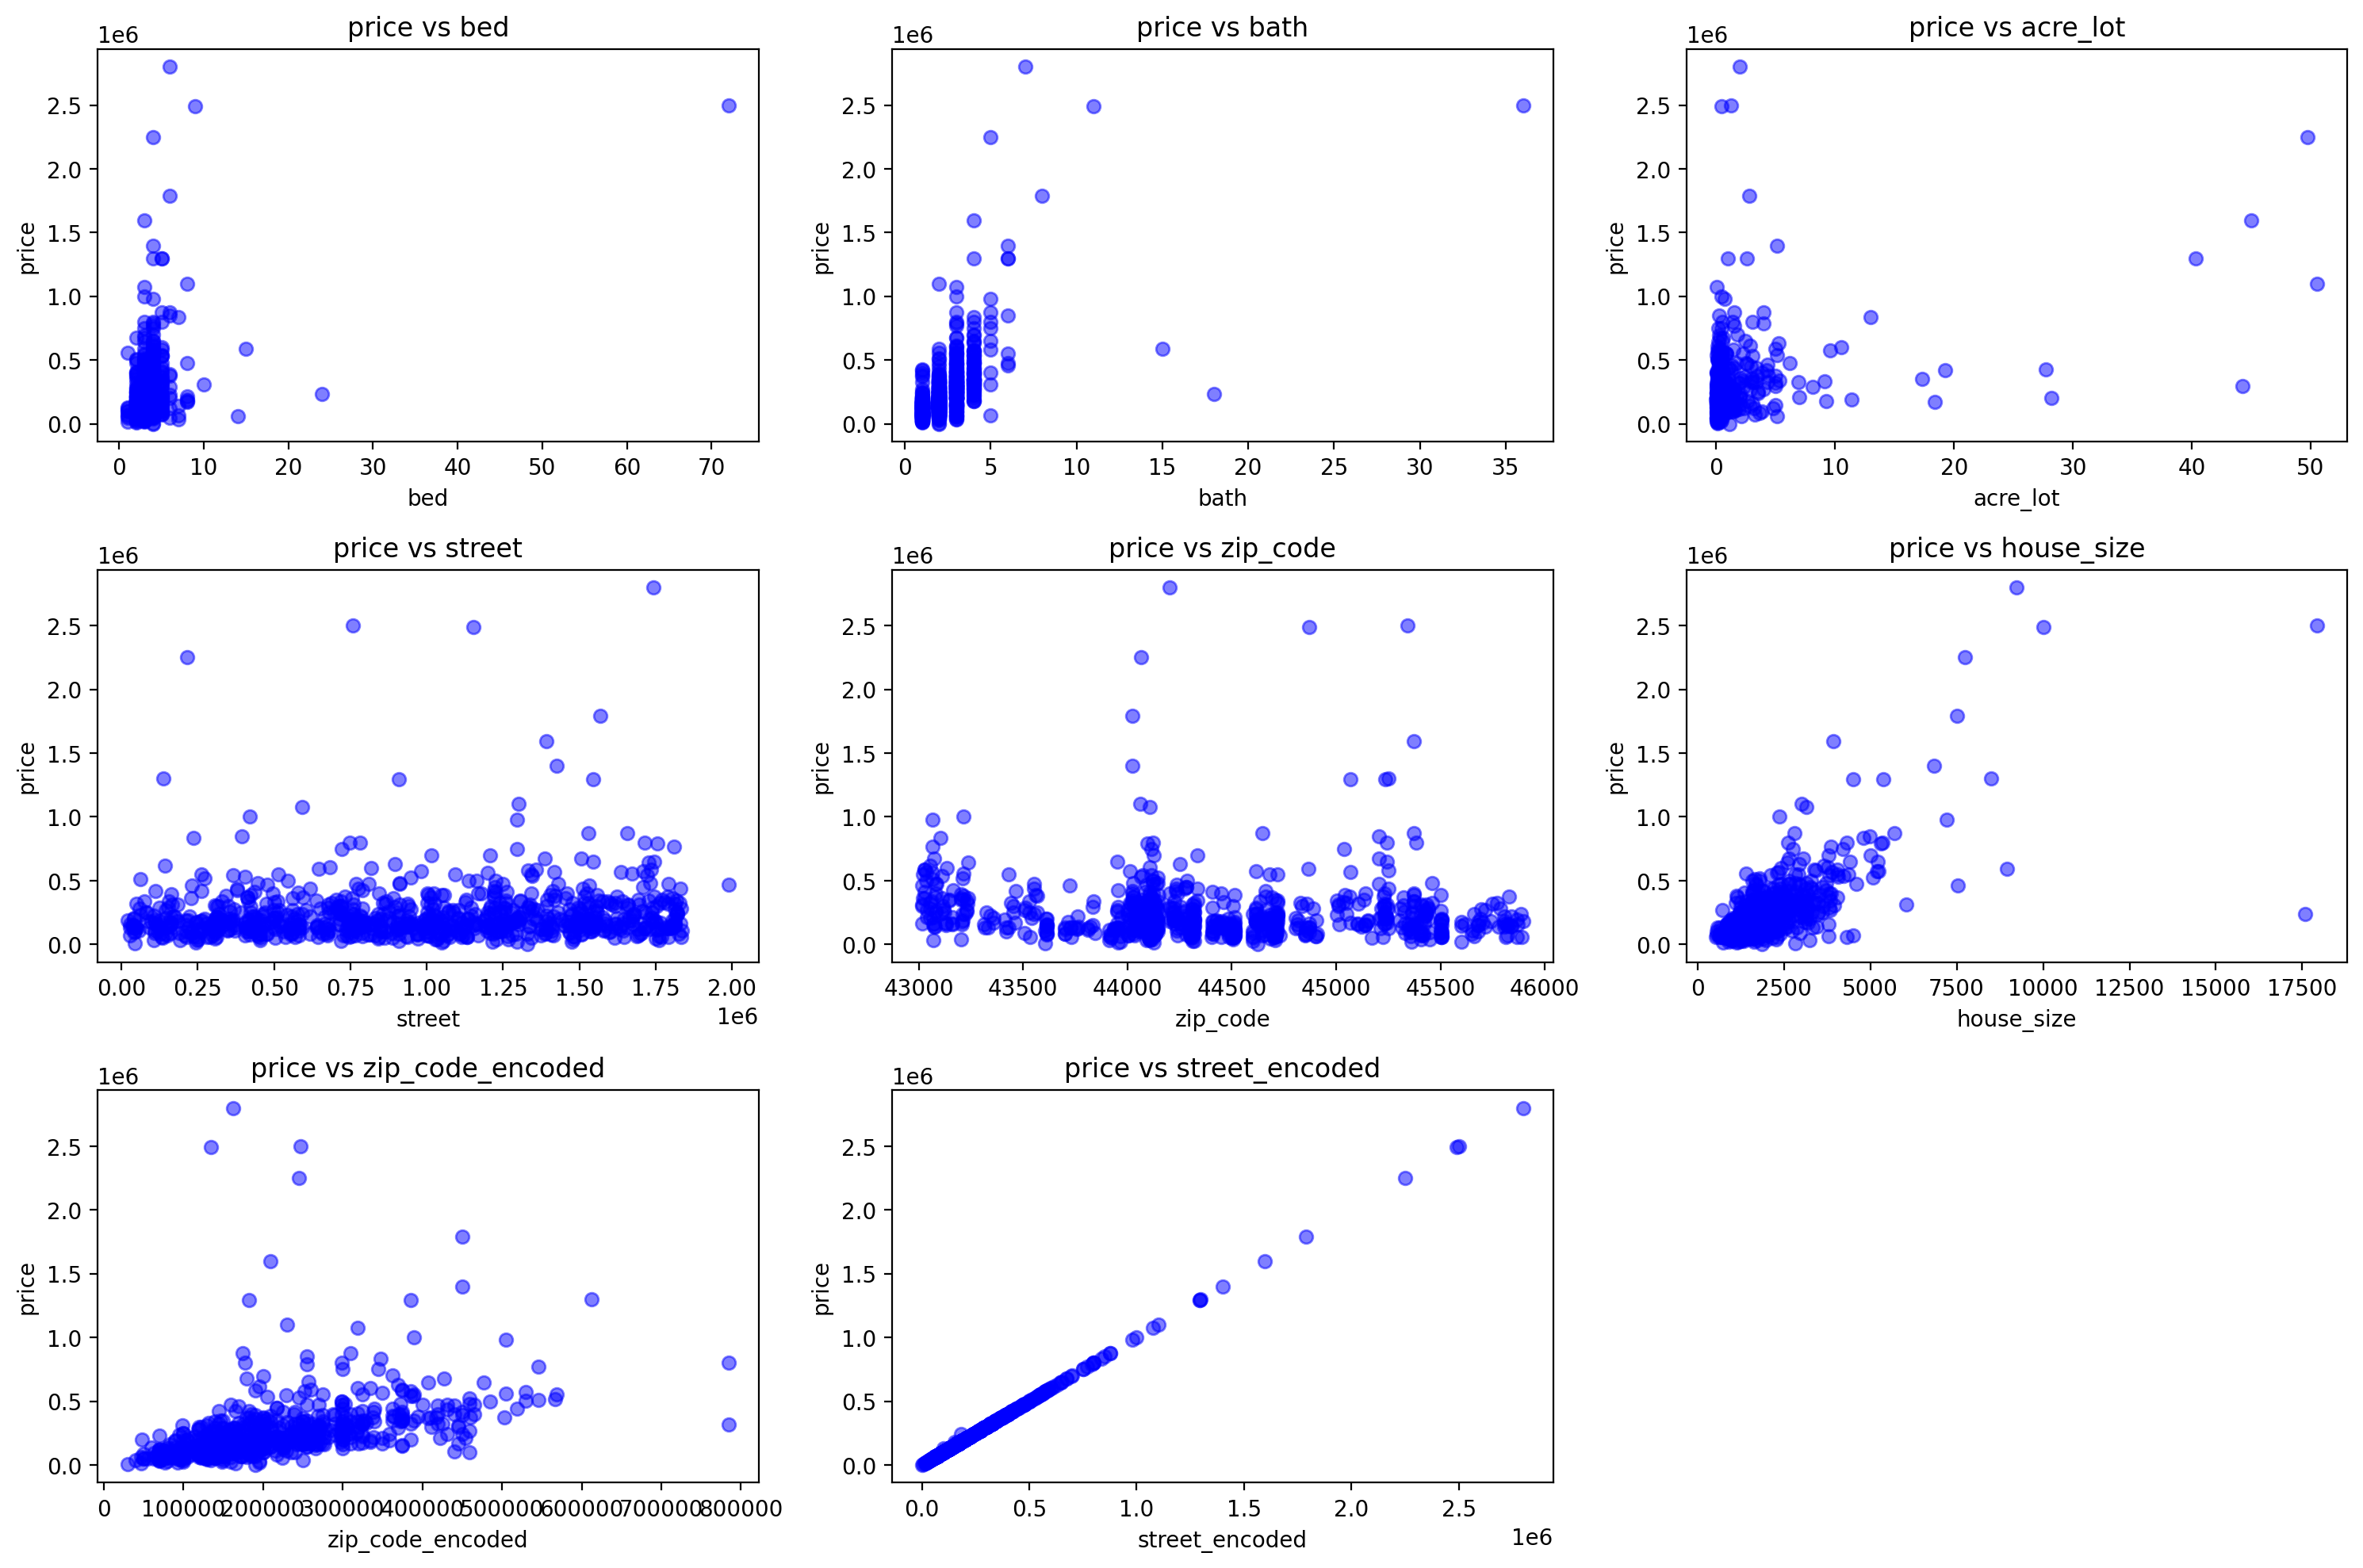

In [10]:
percentile_99 = {}
for col in data.columns:
    percentile_99[col] = data[col].quantile(0.99)

mask = (data <= percentile_99)
data = data[mask.all(axis=1)]

print(data.describe())
data.shape



##Scatter Plot

In [ ]:
# Creating scatter plots

# Define the response variable (target)
y_response = data['price']

# Create scatter plots for each predictor against the target variable
predictor_cols = [col for col in data.columns if col != 'price']

plt.figure(figsize=(15, 10))  # Set figure size

for i, col in enumerate(predictor_cols):
    plt.subplot(4, 4, i + 1)
    plt.scatter(data[col], data['price'], color='blue', alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('price')
    plt.title(f'price vs {col}')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


##Split for training and standardizing

In [ ]:
# Import the necessary function
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Set the random seed for reproducibility
np.random.seed(934)

# Define X and y
X = data.drop('price', axis=1)  # Features (all columns except 'price')
y = data['price']  # Target variable

total_rows = len(X)
train_size = int(0.8 * total_rows)

# Split the dataset into train and validation sets
x_train, x_valid, y_train, y_valid = train_test_split(X, y, train_size=train_size, random_state=934)

# Check the shapes of the train and validation sets
print(x_train.shape)
print(x_valid.shape)

# Standardize the data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)


print("Means:", np.mean(x_train_scaled, axis=0))
print("Stds:", np.std(x_train_scaled, axis=0))

In [ ]:
print("x_train_scaled shape:", x_train_scaled.shape)
print("y_train shape:", y_train.shape)
print("x_train_df shape:", x_train_df.shape)
print("train_data shape:", train_data.shape)

#Clustering Algorithms


##k-means


In [ ]:
from sklearn.cluster import KMeans


# Apply K-means to the scaled training data
kmeans = KMeans(n_clusters=2, random_state=934)
x_train_clusters = kmeans.fit_predict(x_train_scaled)


# Build x_train_df with original index
x_train_df = pd.DataFrame(x_train_scaled, columns=X.columns, index=x_train.index)
x_train_df['cluster'] = x_train_clusters

# Join with y_train using index alignment
train_data = x_train_df.join(y_train, how='inner')  # 'inner' drops unmatched rows


# Optionally, predict clusters for the validation set
x_valid_clusters = kmeans.predict(x_valid_scaled) # Predict

x_valid_df = pd.DataFrame(x_valid_scaled, columns=X.columns, index=x_valid.index)
x_valid_df['cluster'] = x_valid_clusters

#valid_data = pd.concat([x_valid_df, y_valid.reset_index(drop=True)], axis=1) #
valid_data = x_valid_df.join(y_valid, how='inner')  # 'inner' drops unmatched rows


# Quick check of cluster assignments and average prices per cluster
cluster_summary = train_data.groupby('cluster').agg({'price': ['mean', 'count']})
print("Cluster Summary:\n", cluster_summary)

# Print cluster centers in scaled space
print("Cluster Centers:\n", kmeans.cluster_centers_)


In [ ]:
#Double Checking data frame sizes make sense

print("x_valid_scaled shape:", x_valid_scaled.shape)
print("y_valid shape:", y_valid.shape)
print("x_valid_df shape:", x_valid_df.shape)
print("valid_data shape:", valid_data.shape)

print(valid_data.head())

###Plot K-means regions

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Reduce dimensionality for visualization using PCA
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train_scaled)
x_valid_pca = pca.transform(x_valid_scaled)

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'PC1': x_train_pca[:, 0],
    'PC2': x_train_pca[:, 1],
    'Cluster': x_train_clusters,
    'Set': 'Train'
})
valid_plot_data = pd.DataFrame({
    'PC1': x_valid_pca[:, 0],
    'PC2': x_valid_pca[:, 1],
    'Cluster': x_valid_clusters,
    'Set': 'Validation'
})
plot_data = pd.concat([plot_data, valid_plot_data])

# Plot clusters with colors for clusters and markers for train/validation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, x='PC1', y='PC2', hue='Cluster', style='Set', s=100)
plt.title('PCA of Clusters (Train vs Validation)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# Quick pie chart for train-test split
split_counts = pd.Series({'Train': len(x_train), 'Validation': len(x_valid)})
plt.figure(figsize=(5, 5))
plt.pie(split_counts, labels=split_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Train vs Validation Split')
plt.show()

# Print explained variance ratio to see how much info PCA captures
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

###Summarize Characteristics of each group

These are being unstandardized so the numbers make sense.

In [ ]:
# Group by cluster and summarize key features
cluster_analysis = train_data.groupby('cluster').agg({
    'price': ['mean', 'median'],
    'bed': ['mean', 'median'],
    'bath': ['mean', 'median'],
    'acre_lot': ['mean', 'median'],
    'house_size': ['mean', 'median'],
    'zip_code_encoded': ['mean', 'median']
})


features = ['bed', 'bath', 'acre_lot', 'house_size', 'zip_code_encoded']
unstandardized_cluster_analysis = cluster_analysis.copy()

for feature in features:
    # Get the column index from x_train
    col_index = list(x_train.columns).index(feature)
    original_mean = scaler.mean_[col_index]
    original_scale = scaler.scale_[col_index]

    unstandardized_cluster_analysis[(feature, 'mean')] = (
        cluster_analysis[(feature, 'mean')] * original_scale + original_mean
    )
    unstandardized_cluster_analysis[(feature, 'median')] = (
        cluster_analysis[(feature, 'median')] * original_scale + original_mean
    )
print("Unstandardized Cluster Characteristics:\n", unstandardized_cluster_analysis)




##DBSCAN


In [ ]:
from sklearn.cluster import DBSCAN
import pandas as pd

# Apply DBSCAN to the scaled training data
dbscan = DBSCAN(eps=.75, min_samples=1000)  # Tweak eps and min_samples as needed
x_train_clusters = dbscan.fit_predict(x_train_scaled)

# Convert scaled x_train back to DataFrame with original column names
x_train_df = pd.DataFrame(x_train_scaled, columns=X.columns, index=x_train.index)
x_train_df['cluster'] = x_train_clusters

# Merge with y_train to include 'price'
train_data = pd.concat([x_train_df, y_train.reset_index(drop=True)], axis=1)

# Predict clusters for validation set (DBSCAN doesn’t “predict” new points, so we fit again or use training labels)
# For simplicity, let’s just check training clusters here

# Quick check of cluster assignments and average prices per cluster
cluster_summary = train_data.groupby('cluster').agg({'price': ['mean', 'count']})
print("Cluster Summary:\n", cluster_summary)

# -1 in clusters means noise (outliers), other numbers are clusters
print(f"Number of clusters (excluding noise): {len(set(x_train_clusters)) - (1 if -1 in x_train_clusters else 0)}")
print(f"Number of noise points: {list(x_train_clusters).count(-1)}")

###Visualize DBSCAN

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming your DBSCAN code from before
pca = PCA(n_components=2)  # Reduce to 2D
x_train_pca = pca.fit_transform(x_train_scaled)

# Scatter plot with DBSCAN clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_train_pca[:, 0], x_train_pca[:, 1], c=x_train_clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster Label (-1 = Noise)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('DBSCAN Clusters in 2D PCA Space')
plt.show()

# Optional: Explained variance ratio to see how much PCA captures
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

#Regression Models



##Regression K-means groups

###Linear Regression (k-means)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Dictionary to store results for each cluster
cluster_results = {}

# Iterate over each cluster
for cluster_id in range(4):
    # Select data points belonging to the current cluster
    train_subset = train_data[train_data['cluster'] == cluster_id].dropna()
    valid_subset = valid_data[valid_data['cluster'] == cluster_id].dropna()

    # Ensure the cluster has validation data
    if valid_subset.empty:
        print(f"Skipping Cluster {cluster_id}: No validation data available.")
        continue

    # Extract X (features) and y (target)
    x_train_cluster = train_subset.drop(columns=['price', 'cluster'])
    y_train_cluster = train_subset['price']
    x_valid_cluster = valid_subset.drop(columns=['price', 'cluster'])
    y_valid_cluster = valid_subset['price']

    # Check for NaNs after filtering
    if y_valid_cluster.isna().any() or x_valid_cluster.isna().any().any():
        print(f"Skipping Cluster {cluster_id}: NaN values detected after filtering.")
        continue

    # Initialize and fit linear regression model
    lm = LinearRegression()
    lm.fit(x_train_cluster, y_train_cluster)

    # Make predictions
    y_pred_cluster = lm.predict(x_valid_cluster)

    # Compute evaluation metrics
    mse = mean_squared_error(y_valid_cluster, y_pred_cluster)
    r2 = r2_score(y_valid_cluster, y_pred_cluster)

    # Adjusted R Squared
    n = len(y_valid_cluster)
    p = x_train_cluster.shape[1]
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else None

    # Store results
    cluster_results[cluster_id] = {
        'Coefficients': lm.coef_,
        'Intercept': lm.intercept_,
        'MSE': mse,
        'R2': r2,
        'Adjusted R2': adjusted_r2
    }

    # Print results
    print(f"Cluster {cluster_id}:")
    print("Coefficients:", lm.coef_)
    print("Intercept:", lm.intercept_)
    print(f"MSE: {mse:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Adjusted R²: {adjusted_r2:.4f}\n")

### Spline Regression (k-means)


In [ ]:
# ---------------------------
# Spline Regression for Each Cluster
# ---------------------------
# Dictionary to store models and evaluation results per cluster
models = {}
results = {}

# Iterate through each cluster
for cluster in sorted(train_data['cluster'].unique()):
    # Filter data for the current cluster
    train_cluster = train_data[train_data['cluster'] == cluster]
    valid_cluster = valid_data[valid_data['cluster'] == cluster]

    # Prepare training features and target.
    # Drop the cluster column and target column ('price') from features.
    X_train_cluster = train_cluster.drop(columns=['cluster', 'price'])
    y_train_cluster = train_cluster['price']

    X_valid_cluster = valid_cluster.drop(columns=['cluster', 'price'])
    y_valid_cluster = valid_cluster['price']

    # Create a spline regression pipeline (cubic splines with 5 knots)
    spline_model = make_pipeline(
        SplineTransformer(degree=3, n_knots=5, include_bias=False),
        LinearRegression()
    )

    # Fit the model on the cluster-specific training data
    spline_model.fit(X_train_cluster, y_train_cluster)

    # Predict target values on the validation set for the cluster
    y_pred_cluster = spline_model.predict(X_valid_cluster)

    # Evaluate the performance for the current cluster
    mse = mean_squared_error(y_valid_cluster, y_pred_cluster)
    r2 = r2_score(y_valid_cluster, y_pred_cluster)

    # Save the model and its evaluation results
    models[cluster] = spline_model
    results[cluster] = {'mse': mse, 'r2': r2}

    # Print the results
    print(f"\nCluster {cluster} - Spline Model Performance:")
    print("Mean Squared Error:", mse)
    print("R^2 Score:", r2)

### LASSO Regression (k-means)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# Define the list of alpha values to test
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]

# Dictionary to store R² scores for each cluster
cluster_r2 = {}

# Iterate over each unique cluster from the training data
for cluster in sorted(train_data['cluster'].unique()):
    # Prepare cluster-specific training and validation data
    train_cluster = train_data[train_data['cluster'] == cluster]
    valid_cluster = valid_data[valid_data['cluster'] == cluster]

    # Drop the 'cluster' column and target ('price') from features
    X_train_cluster = train_cluster.drop(columns=['cluster', 'price'])
    y_train_cluster = train_cluster['price']
    X_valid_cluster = valid_cluster.drop(columns=['cluster', 'price'])
    y_valid_cluster = valid_cluster['price']

    # Initialize list to store R² scores for current cluster
    cluster_r2[cluster] = []

    # Loop over each alpha value
    for a in alphas:
        lasso = Lasso(alpha=a, max_iter=10000)  # Increase max_iter if needed
        lasso.fit(X_train_cluster, y_train_cluster)
        y_pred = lasso.predict(X_valid_cluster)
        r2 = r2_score(y_valid_cluster, y_pred)
        cluster_r2[cluster].append(r2)
        print(f"Cluster {cluster}, Alpha: {a} -> R²: {r2:.4f}")

# Plot R² vs. Alpha for each cluster
plt.figure(figsize=(8, 5))
for cluster in sorted(cluster_r2.keys()):
    plt.plot(alphas, cluster_r2[cluster], marker='o', label=f'Cluster {cluster}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('LASSO: R² Score over Different Alpha Values by Cluster')
plt.legend()
plt.show()


###Experimenting with k-folds cross validation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold

# Define the list of alpha values to test
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]

# Set up k-fold cross-validation (e.g., 5-fold)
cv = KFold(n_splits=5, shuffle=True, random_state=934)

# Dictionary to store average cross-validated R² scores for each cluster
cluster_r2 = {}

# Iterate over each unique cluster from the training data
for cluster in sorted(train_data['cluster'].unique()):
    # Prepare cluster-specific training data
    train_cluster = train_data[train_data['cluster'] == cluster]

    # Separate features and target, dropping the cluster column and target ('price') from features
    X_train_cluster = train_cluster.drop(columns=['cluster', 'price'])
    y_train_cluster = train_cluster['price']

    # Initialize list to store average R² scores for the current cluster
    cluster_r2[cluster] = []

    # Loop over each alpha value
    for a in alphas:
        # Define LASSO with the current alpha
        lasso = Lasso(alpha=a, max_iter=10000)
        # Perform cross-validation; scores are R² values per fold
        scores = cross_val_score(lasso, X_train_cluster, y_train_cluster, cv=cv, scoring='r2')
        r2_mean = scores.mean()
        cluster_r2[cluster].append(r2_mean)
        print(f"Cluster {cluster}, Alpha: {a} -> Cross Val R²: {r2_mean:.4f}")

# Plot R² vs. Alpha for each cluster
plt.figure(figsize=(8, 5))
for cluster in sorted(cluster_r2.keys()):
    plt.plot(alphas, cluster_r2[cluster], marker='o', label=f'Cluster {cluster}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Average R² Score (5-fold CV)')
plt.title('LASSO: Cross-Validated R² Score over Different Alpha Values by Cluster')
plt.legend()
plt.show()


### XGBoost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold

# Define a list of learning rates to test
learning_rates = [0.001, 0.01, 0.1, 0.3, 0.5, 1]

# Set up 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=934)

# Dictionary to store average cross-validated R² scores for each cluster
cluster_r2_xgb = {}

# Iterate over each cluster from your training data
for cluster in sorted(train_data['cluster'].unique()):
    # Filter cluster-specific training data
    train_cluster = train_data[train_data['cluster'] == cluster]
    X_train_cluster = train_cluster.drop(columns=['cluster', 'price'])
    y_train_cluster = train_cluster['price']

    # Initialize a list to hold R² scores for the current cluster
    cluster_r2_xgb[cluster] = []

    # Loop over each learning rate
    for lr in learning_rates:
        # Initialize the XGBoost regressor with the current learning rate.
        # Other parameters (like n_estimators) are set to defaults.
        xgb_model = XGBRegressor(learning_rate=lr, n_estimators=100, random_state=42)
        # Evaluate with cross-validation (R² scoring)
        scores = cross_val_score(xgb_model, X_train_cluster, y_train_cluster, cv=cv, scoring='r2')
        avg_r2 = scores.mean()
        cluster_r2_xgb[cluster].append(avg_r2)
        print(f"Cluster {cluster}, Learning Rate: {lr} -> Average CV R²: {avg_r2:.4f}")

# Plot R² vs. Learning Rate for each cluster
plt.figure(figsize=(8, 5))
for cluster in sorted(cluster_r2_xgb.keys()):
    plt.plot(learning_rates, cluster_r2_xgb[cluster], marker='o', label=f'Cluster {cluster}')
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Average CV R² Score (5-fold)')
plt.title('XGBoost: Cross-Validated R² Score over Different Learning Rates by Cluster')
plt.legend()
plt.show()


## Regression Whole dataset


### Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

#Initialize
lm1 = LinearRegression()

lm1.fit(x_train_scaled, y_train) #Fit the Model to the training data

y_pred = lm1.predict(x_valid_scaled) #Make Predictions on the validation set

# Print model coefficients
print("Coefficients:", lm1.coef_)
print("Intercept:", lm1.intercept_)

from sklearn.metrics import mean_squared_error

# Compute MSE for Ridge Prediction:
mse_valid_lm = mean_squared_error(y_valid, y_pred)

# Print results
print(f"Validation MSE: {mse_valid_lm:.4f}")

# R Squared
from sklearn.metrics import r2_score
r2 = r2_score(y_valid, y_pred)
print("R² Score:", r2)

# Adjusted R Squared
n = len(y_valid)
p = X.shape[1]  # number of features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R²:", adjusted_r2)


###Projection Pursuit Regression

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Simple PPR: Project onto random directions, fit polynomials
n_terms = 3  # Number of projection terms
np.random.seed(934)

# Store predictions
y_pred_train = np.zeros_like(y_train)
y_pred_valid = np.zeros_like(y_valid)

for _ in range(n_terms):
    # Random projection direction
    weights = np.random.randn(x_train_scaled.shape[1])
    weights /= np.linalg.norm(weights)  # Unit vector

    # Project data
    proj_train = x_train_scaled.dot(weights)
    proj_valid = x_valid_scaled.dot(weights)

    # Fit a polynomial (degree 2) on the projection
    poly = PolynomialFeatures(degree=2)
    proj_train_poly = poly.fit_transform(proj_train.reshape(-1, 1))
    proj_valid_poly = poly.transform(proj_valid.reshape(-1, 1))

    # Linear regression on polynomial features
    lr = LinearRegression()
    lr.fit(proj_train_poly, y_train)

    # Add predictions
    y_pred_train += lr.predict(proj_train_poly)
    y_pred_valid += lr.predict(proj_valid_poly)

# Average the predictions (optional refinement)
y_pred_valid /= n_terms

# Evaluate
mse = mean_squared_error(y_valid, y_pred_valid)
r2 = r2_score(y_valid, y_pred_valid)
n = len(y_valid)
p = x_valid_scaled.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Validation MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

###Spline Regression


In [ ]:
# Import necessary modules for spline transformation, regression, and evaluation
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Create a pipeline that applies a spline transformation followed by linear regression.
# Here, degree=3 creates cubic splines and n_knots=5 splits the feature range into 5 regions.
spline_model = make_pipeline(
    SplineTransformer(degree=3, n_knots=5, include_bias=False),
    LinearRegression()
)

# Fit the model on the training data
spline_model.fit(x_train_scaled, y_train)

# Predict the target values for the validation set
y_pred = spline_model.predict(x_valid_scaled)

# Evaluate the model's performance using Mean Squared Error and R^2 score
mse = mean_squared_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print("Spline Model Performance on Validation Data:")
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)


###XGBoost

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the XGBoost regressor
xgb_model = XGBRegressor(learning_rate=0.1, n_estimators=100, random_state=42)

# Fit the model on the training data
xgb_model.fit(x_train_scaled, y_train)

# Make predictions on the validation set
y_pred = xgb_model.predict(x_valid_scaled)

# Compute evaluation metrics
mse_valid_xgb = mean_squared_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print("XGBoost Validation MSE: {:.4f}".format(mse_valid_xgb))
print("XGBoost R² Score:", r2)

# Compute Adjusted R²
n = len(y_valid)
p = X.shape[1]  # number of features
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R²:", adjusted_r2)


#Old Stuff


In [ ]:
# For acre_lot
lower_acre = data['acre_lot'].quantile(0.01)
upper_acre = data['acre_lot'].quantile(0.99)
data = data[(data['acre_lot'] >= lower_acre) & (data['acre_lot'] <= upper_acre)]

# For house_size
lower_size = data['house_size'].quantile(0.01)
upper_size = data['house_size'].quantile(0.99)
data = data[(data['house_size'] >= lower_size) & (data['house_size'] <= upper_size)]

# For Price
lower_price = data['price'].quantile(0.01)
upper_price = data['price'].quantile(0.99)
data = data[(data['price'] >= lower_price) & (data['price'] <= upper_price)]



In [ ]:
# Import the seaborn library
import seaborn as sns

# Compute the correlation matrix
corr_matrix = data.corr()

# Display correlation matrix
# print(corr_matrix)

# Set figure size for better readability
plt.figure(figsize=(10, 8))

# Create a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Set title
plt.title("Correlation Matrix", fontsize=14)

# Show the plot
plt.show()

## Simple Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

#Initialize
lm1 = LinearRegression()

lm1.fit(x_train_scaled, y_train) #Fit the Model to the training data

y_pred = lm1.predict(x_valid_scaled) #Make Predictions on the validation set

# Print model coefficients
print("Coefficients:", lm1.coef_)
print("Intercept:", lm1.intercept_)

from sklearn.metrics import mean_squared_error

# Compute MSE for Ridge Prediction:
mse_valid_lm = mean_squared_error(y_valid, y_pred)

# Print results
print(f"Validation MSE: {mse_valid_lm:.4f}")

# R Squared
from sklearn.metrics import r2_score
r2 = r2_score(y_valid, y_pred)
print("R² Score:", r2)

# Adjusted R Squared
n = len(y_valid)
p = X.shape[1]  # number of features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R²:", adjusted_r2)


##Troubleshooting Model

In [ ]:
from sklearn.metrics import mean_squared_error

# Naive: predict mean of y_train for all x_valid
y_mean = y_train.mean()
naive_preds = [y_mean] * len(y_valid)
naive_mse = mean_squared_error(y_valid, naive_preds)
print("Naive MSE:", naive_mse)


from sklearn.metrics import r2_score
r2 = r2_score(y_valid, y_pred)
print("R² Score:", r2)


n = len(y_valid)
p = X.shape[1]  # number of features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R²:", adjusted_r2)

data.shape[1]

## Ridge Regression


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Initialize and fit Ridge regression model
ridge = Ridge(alpha=1)  # You can adjust alpha (regularization strength)
ridge.fit(x_train_scaled, y_train)

# Predictions
y_pred_ridge = ridge.predict(x_valid_scaled)

# Print coefficients

print("Ridge Coefficients:", ridge.coef_)

# Compute MSE for Ridge Prediction:
mse_valid_ridge = mean_squared_error(y_valid, y_pred_ridge)

# Print results
print(f"Validation MSE: {mse_valid_ridge:.4f}")

# R Squared
from sklearn.metrics import r2_score
r2 = r2_score(y_valid, y_pred_ridge)
print("R² Score:", r2)

# Adjusted R Squared
n = len(y_valid)
p = X.shape[1]  # number of features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R²:", adjusted_r2)


In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]
coefs = []
r2s = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(x_train_scaled, y_train)
    coefs.append(ridge.coef_)
    y_pred = ridge.predict(x_valid_scaled)
    r2 = r2_score(y_valid, y_pred)
    r2s.append(r2)
    print(f"Alpha: {a} -> R²: {r2:.4f}, Coefficients: {ridge.coef_}")

# Optionally, visualize how coefficients change with alpha
import matplotlib.pyplot as plt
coefs = np.array(coefs)
plt.figure(figsize=(10,6))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=f'Feature {i}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Paths for Ridge Regression')
plt.legend()
plt.show()

# Optionally, plot R² vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, r2s, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('R² Score for Ridge Regression over Different Alpha Values')
plt.show()

In [ ]:
from sklearn.linear_model import Lasso

# Initialize and fit Lasso regression model
lasso = Lasso(alpha=100)  # Adjust alpha to control sparsity
lasso.fit(x_train_scaled, y_train)

# Predictions
y_pred_lasso = lasso.predict(x_valid_scaled)

# Print selected features (nonzero coefficients)
selected_features = x_train.columns[lasso.coef_ != 0]
print("Selected Features:", selected_features)
print("Lasso Coefficients:", lasso.coef_)

# Compute MSE for Ridge Prediction:
mse_valid_lasso = mean_squared_error(y_valid, y_pred_lasso)

# Print results
print(f"Validation MSE: {mse_valid_lasso:.4f}")

# R Squared
from sklearn.metrics import r2_score
r2 = r2_score(y_valid, y_pred_lasso)
print("R² Score:", r2)

# Adjusted R Squared
n = len(y_valid)
p = X.shape[1]  # number of features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R²:", adjusted_r2)


In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]
coefs = []
r2s = []



for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(x_train_scaled, y_train)
    coefs.append(lasso.coef_)
    y_pred = lasso.predict(x_valid_scaled)
    r2 = r2_score(y_valid, y_pred)
    r2s.append(r2)
    print(f"Alpha: {a} -> R²: {r2:.4f}, Coefficients: {lasso.coef_}")

# Optionally, visualize how coefficients change with alpha
import matplotlib.pyplot as plt
coefs = np.array(coefs)
plt.figure(figsize=(10,6))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=f'Feature {i}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Paths for Ridge Regression')
plt.legend()
plt.show()

# Optionally, plot R² vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, r2s, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('R² Score for Ridge Regression over Different Alpha Values')
plt.show()

# Bayesian MCMC - Haven't done anything with this yet

In [ ]:
with pm.Model() as model1:
    sigma = pm.Exponential('sigma', 1)
    beta1 = pm.Normal('beta1', mu=-0.5, sigma=1)
    beta2 = pm.Normal('beta2', mu=1, sigma=1)
    beta3 = pm.Normal('beta3', mu=0.4, sigma=1)
    beta4 = pm.Normal('beta4', mu=0.3, sigma=1)
    beta5 = pm.Normal('beta5', mu=-2, sigma=1)
    beta6 = pm.Normal('beta6', mu=3.05, sigma=1)
    beta7 = pm.Normal('beta7', mu=-0.05, sigma=1)
    beta8 = pm.Normal('beta8', mu=-3, sigma=1)
    beta9 = pm.Normal('beta9', mu=2.5, sigma=1)
    beta10 = pm.Normal('beta10', mu=-2, sigma=1)
    beta11 = pm.Normal('beta11', mu=-2, sigma=1)
    beta12 = pm.Normal('beta12', mu=0.5, sigma=1)
    beta13 = pm.Normal('beta13', mu=-4, sigma=1)

    alpha = pm.Normal('alpha', mu=0, sigma=1)

    _mu = (alpha + beta1*x_train['CRIM'] + beta2*x_train['ZN']+beta3*x_train['INDUS']+beta4*x_train['CHAS']+beta5*x_train['NOX']+beta6*x_train['RM']+beta7*x_train['AGE']+beta8*x_train['DIS']+beta9*x_train['RAD']+beta10*x_train['TAX']+beta11*x_train['PTRATIO']+beta12*x_train['B']+beta13*x_train['LSTAT'])
    mu = pm.Deterministic('mu', _mu) ## we use this so that we can sample the posterior predictive later
    y_new = pm.Normal('price', mu=mu, sigma=sigma, observed=y_train)
    # (draws=1000, tune=1000, chains=4, return_inferencedata=True)
    _model1_samples = pm.sample(1000, tune=1000, chains=4, return_inferencedata=True)
model1_mcmc_samples = _model1_samples.posterior.to_dataframe()

In [ ]:
varnames = ['beta1', 'beta2', 'beta3', 'beta4','beta5', 'beta6', 'beta7', 'beta8', 'beta9', 'beta10','beta11', 'beta12', 'beta13', 'sigma', 'alpha']
display(pm.summary(_model1_samples))

In [ ]:
# Set figure size for better readability
figsize = (7, 2 + 0.4 * len(varnames))  # Dynamic height based on variable count

# Trace plot (optional, if needed)
az.plot_trace(_model1_samples, var_names=varnames, compact=False, figsize=(8, 1.6 * len(varnames)))

# Improved Forest Plot
az.plot_forest(
    _model1_samples,
    var_names=varnames,
    combined=True,
    figsize=figsize,
    hdi_prob=0.94,  # Explicitly setting HDI
    ridgeplot_alpha=0.7,  # Slight transparency for better visualization
    markersize=6  # Larger points
)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()


In [ ]:
#import pymc as pm
#import numpy as np

# Assume '_model1_samples' is your posterior trace
posterior_samples = az.extract(_model1_samples)  # Extract samples

# Get posterior means for coefficients
# Instead of 'beta', access individual betas:
beta1_samples = posterior_samples["beta1"]
beta2_samples = posterior_samples["beta2"]
beta3_samples = posterior_samples["beta3"]
beta4_samples = posterior_samples["beta4"]
beta5_samples = posterior_samples["beta5"]
beta6_samples = posterior_samples["beta6"]
beta7_samples = posterior_samples["beta7"]
beta8_samples = posterior_samples["beta8"]
beta9_samples = posterior_samples["beta9"]
beta10_samples = posterior_samples["beta10"]
beta11_samples = posterior_samples["beta11"]
beta12_samples = posterior_samples["beta12"]
beta13_samples = posterior_samples["beta13"]
alpha_samples = posterior_samples["alpha"]  # Intercept

# Stack beta samples into a single array:
beta_samples = np.stack([beta1_samples, beta2_samples, beta3_samples, beta4_samples,
                         beta5_samples, beta6_samples, beta7_samples, beta8_samples,
                         beta9_samples, beta10_samples, beta11_samples, beta12_samples,
                         beta13_samples], axis=-1)

# Predictive function: y = alpha + X * beta
# Convert alpha_samples to a NumPy array and reshape
alpha_samples_np = alpha_samples.values.reshape(-1, 1)

# Reshape x_valid to match expected shape
x_valid_np = x_valid.values

# Calculate predictions for each sample
y_pred_samples = alpha_samples_np + np.dot(beta_samples, x_valid_np.T)

# Compute mean and 94% credible interval
y_pred_mean = y_pred_samples.mean(axis=0)
y_pred_hdi = az.hdi(y_pred_samples, hdi_prob=0.94)

# Print results
# print("Predicted mean:", y_pred_mean)
# print("94% HDI:", y_pred_hdi)

Tasks:

1. Plot: Prior and posterior distribution of prediction.

2. AIC, abnd BIC:

3. Create a table of beta coefficients - Ridge, Lasso, MCMC


In [ ]:
from sklearn.metrics import mean_squared_error

# Calculate the mean of the posterior predictive samples
y_pred_mean = y_pred_samples.mean(axis=0)  # Average across posterior samples

# Compute MSE using the mean prediction
mse_valid_mcmc = mean_squared_error(y_valid, y_pred_mean)

# Print results
print(f"Validation MSE: {mse_valid_mcmc:.4f}")